# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [43]:
# Setup: Auto-reload e Dispositivo
%load_ext autoreload
%autoreload 2

import os, sys, importlib, torch
sys.path.append(os.path.abspath('src'))
import utils
importlib.reload(utils)

device = utils.get_device()
print(f"Dispositivo: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dispositivo: cuda


In [44]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")


Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [45]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Dataset Sintético | Treino: 70 | Val: 15 | Teste: 15


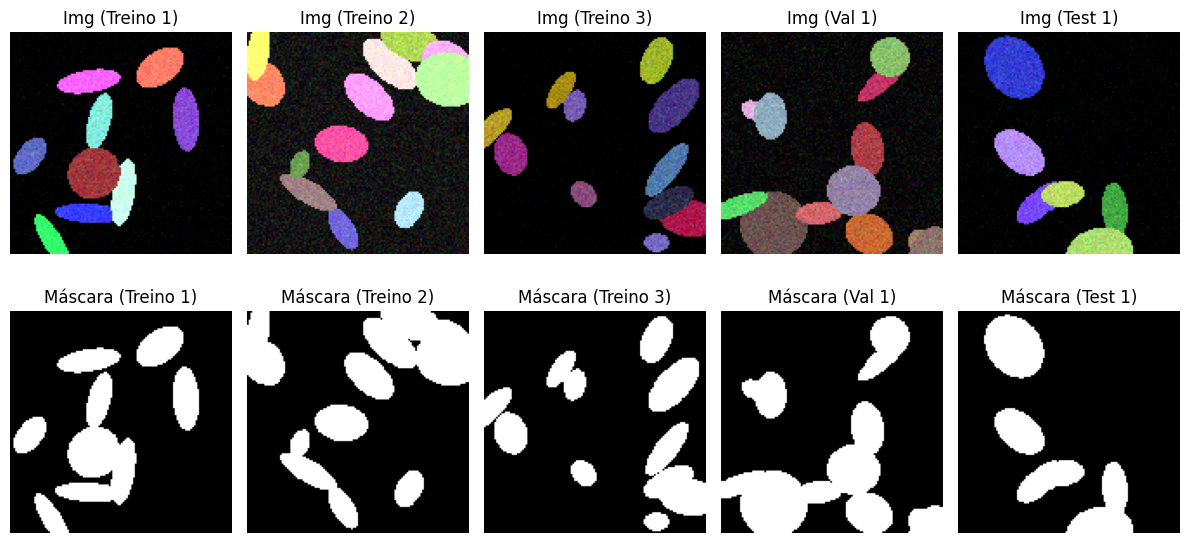

In [46]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [47]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.3730 | Val Loss: 0.5347
Epoch [ 2/10] | Train Loss: 0.2552 | Val Loss: 0.3626
Epoch [ 3/10] | Train Loss: 0.2226 | Val Loss: 0.2717
Epoch [ 4/10] | Train Loss: 0.1959 | Val Loss: 0.2296
Epoch [ 5/10] | Train Loss: 0.1737 | Val Loss: 0.1818
Epoch [ 6/10] | Train Loss: 0.1541 | Val Loss: 0.1541
Epoch [ 7/10] | Train Loss: 0.1368 | Val Loss: 0.1332
Epoch [ 8/10] | Train Loss: 0.1217 | Val Loss: 0.1188
Epoch [ 9/10] | Train Loss: 0.1083 | Val Loss: 0.1069
Epoch [10/10] | Train Loss: 0.0966 | Val Loss: 0.0961


In [48]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9993 | Mean IoU: 0.9985


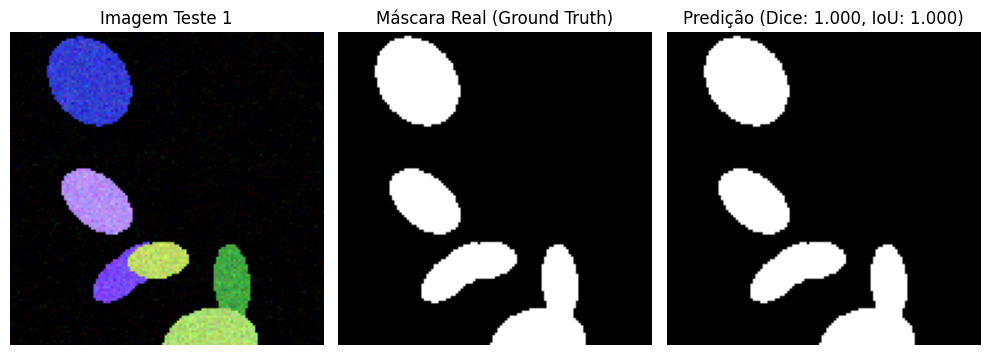

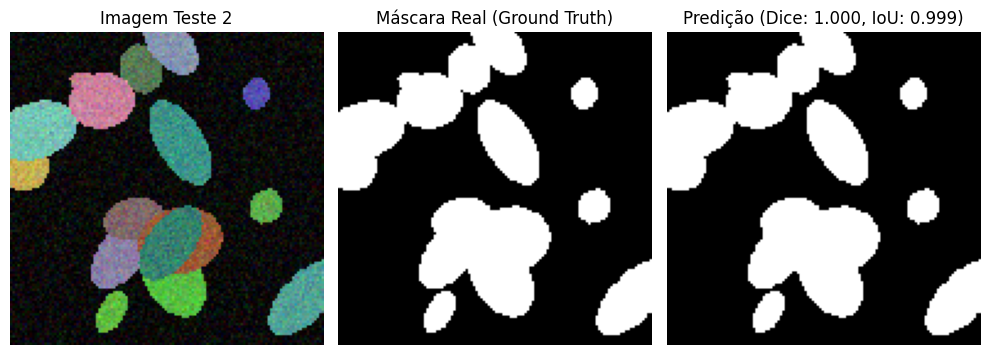

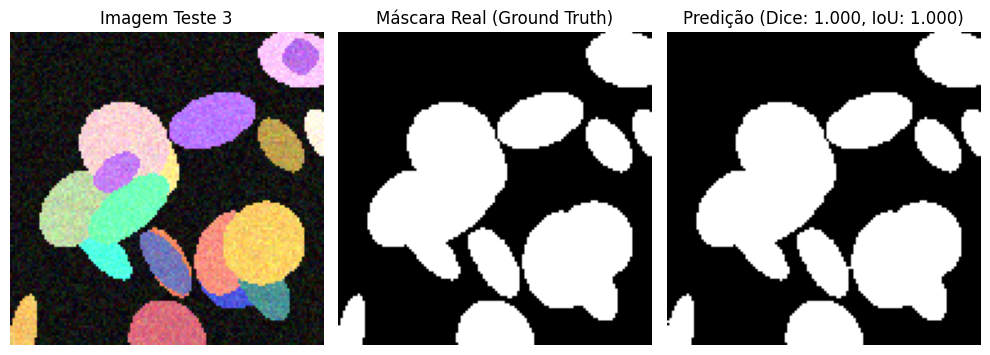

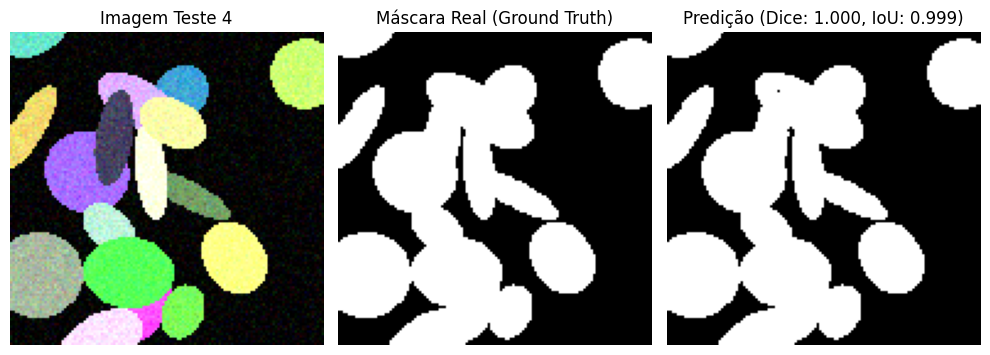

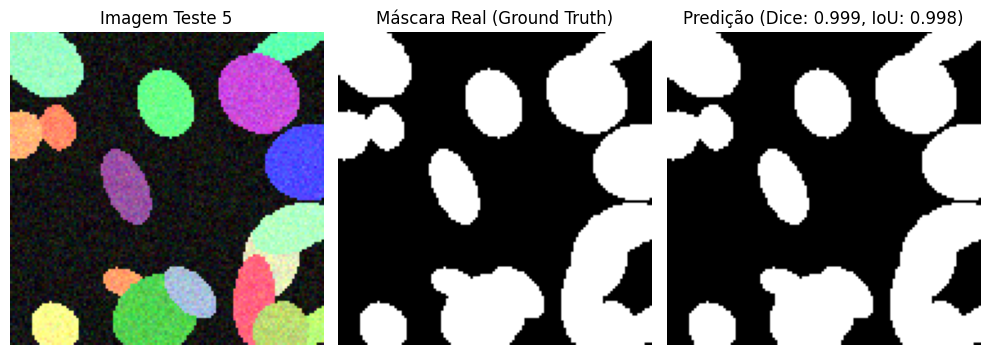

In [49]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [50]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")


Carregando 670 amostras de '../data/stage1_train'...
Aviso: 298/29461 rótulos de instâncias foram perdidos no resize.
Dataset real carregado em 16.80 segundos!
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


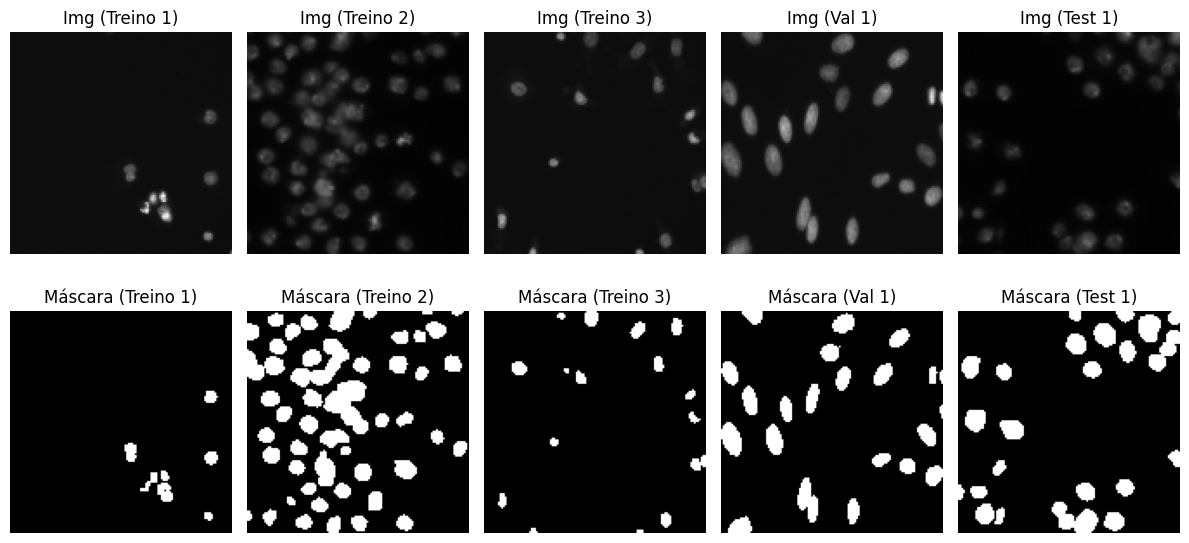

In [51]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [52]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4769 | Val Loss: 0.4246
Epoch [ 2/10] | Train Loss: 0.3146 | Val Loss: 0.2741
Epoch [ 3/10] | Train Loss: 0.2271 | Val Loss: 0.2084
Epoch [ 4/10] | Train Loss: 0.1727 | Val Loss: 0.1663
Epoch [ 5/10] | Train Loss: 0.1365 | Val Loss: 0.1325
Epoch [ 6/10] | Train Loss: 0.1120 | Val Loss: 0.1129
Epoch [ 7/10] | Train Loss: 0.0966 | Val Loss: 0.1019
Epoch [ 8/10] | Train Loss: 0.0857 | Val Loss: 0.0960
Epoch [ 9/10] | Train Loss: 0.0775 | Val Loss: 0.0913
Epoch [10/10] | Train Loss: 0.0732 | Val Loss: 0.0900

[Parte 1 - Item 1] Mean Dice: 0.8789 | Mean IoU: 0.8019


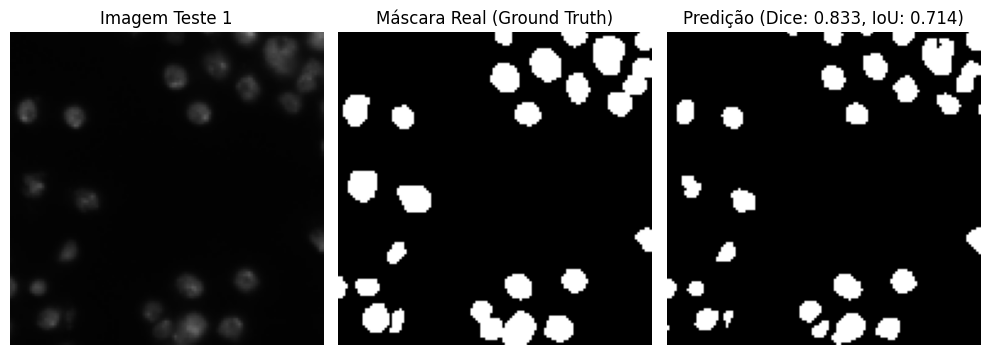

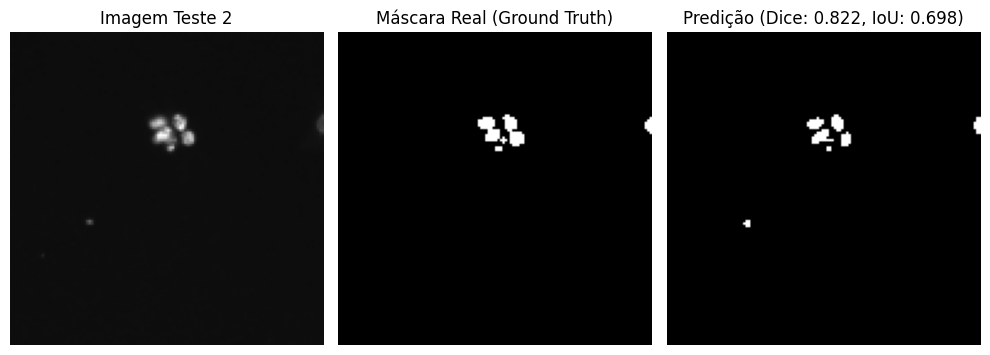

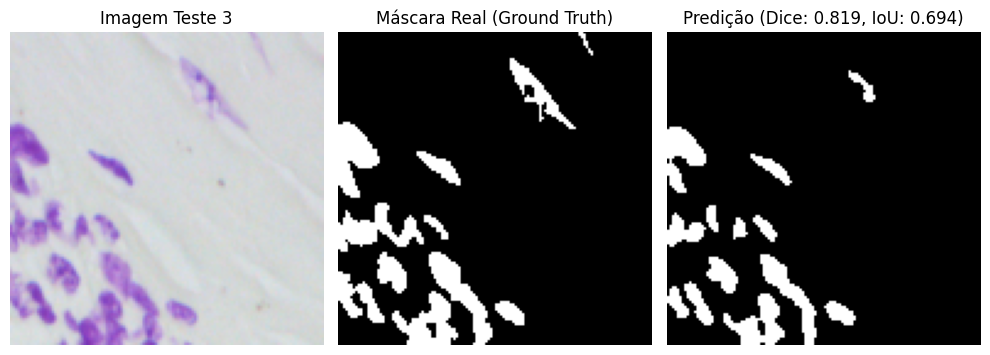

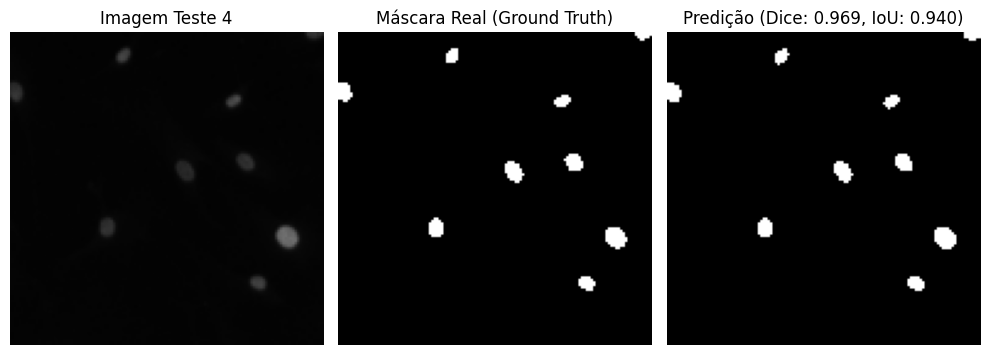

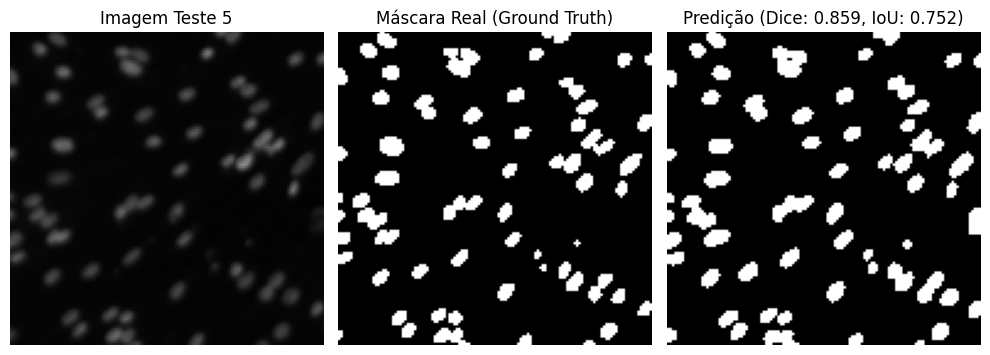

In [53]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


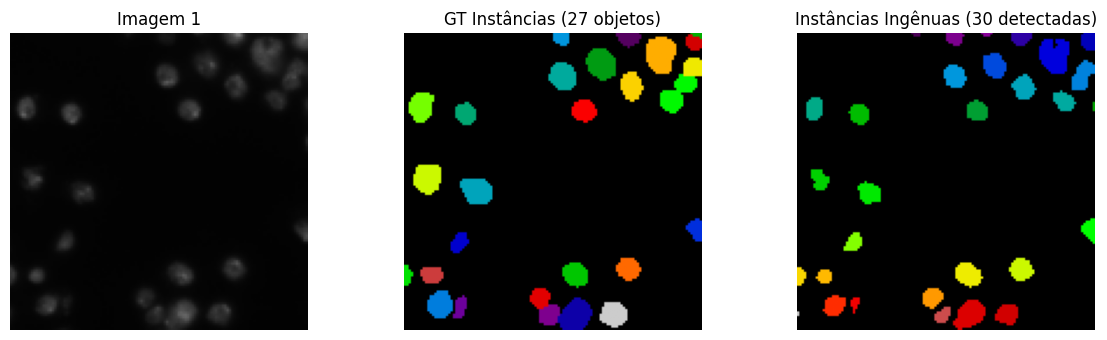

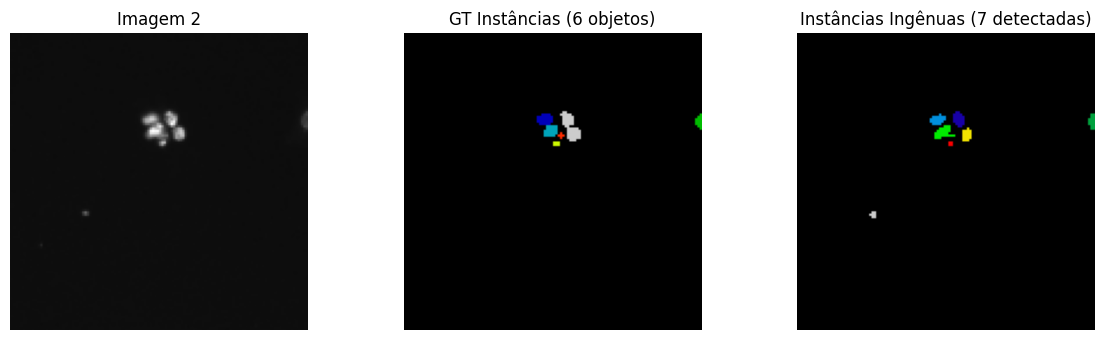

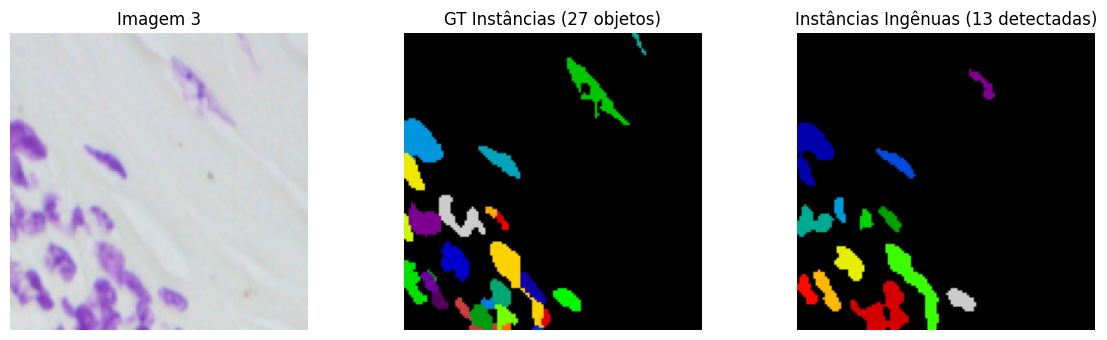

In [54]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [55]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6480
  IoU = 0.55 : AP = 0.6059
  IoU = 0.60 : AP = 0.5835
  IoU = 0.65 : AP = 0.5520
  IoU = 0.70 : AP = 0.5098
  IoU = 0.75 : AP = 0.4716
  IoU = 0.80 : AP = 0.4188
  IoU = 0.85 : AP = 0.3422
  IoU = 0.90 : AP = 0.2032
  IoU = 0.95 : AP = 0.0690

--> mAP@[.50:.95] Final: 0.4404
--> Erro Absoluto Médio de Contagem por Imagem: 10.98 objetos


In [56]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4404 | Erro Médio Contagem = 10.98
Húngaro (Hungarian): mAP@[.50:.95] = 0.4404 | Erro Médio Contagem = 10.98
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


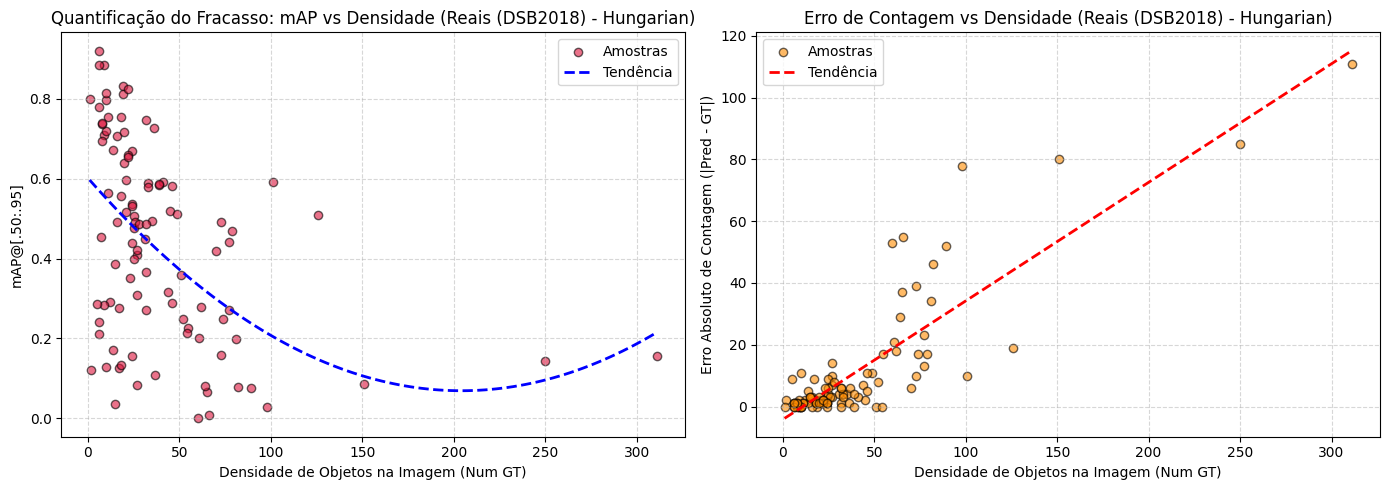

In [57]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.

---
## Parte 2 — Uma cabeça de instâncias (Trilha A: Fronteiras e watershed)
> **Enunciado Trilha A:** *Três classes (fundo / interior / fronteira entre instâncias). Decodificação por watershed com os interiores como marcadores. A perda das classes usa CE balanceada ou focal (slides 74–79). Como gerar o rótulo de fronteira a partir das máscaras individuais? Que espessura? Como pesar a classe fronteira, que é minoritária? A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com as mesmas métricas lado a lado com a baseline.*

In [58]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Alvos gerados! Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")


Alvos gerados! Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.35414392 1.1352271  1.5106288 ]


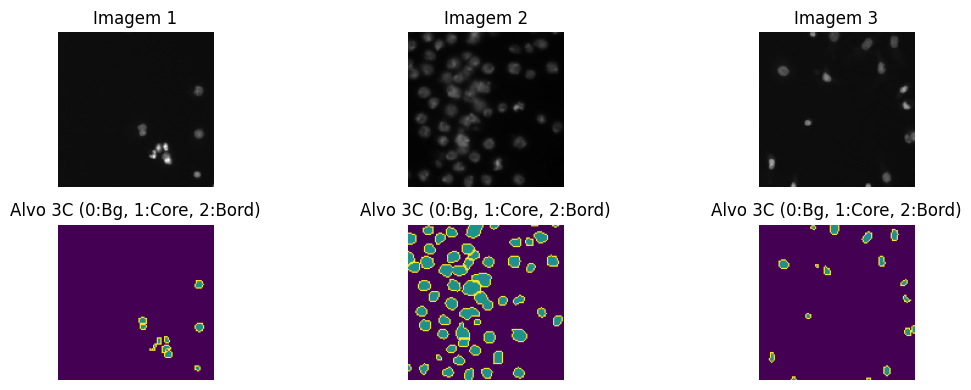

In [59]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)


In [60]:
# Parte 2 (Trilha A) — Treinamento U-Net com Head Modularizado e Cross-Entropy Balanceada
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=True)
utils.train_model_trilha_a(model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device, class_weights=class_weights, gamma=0.0, num_epochs=10, batch_size=16)


Epoch [ 1/10] | Train Loss: 0.3403 | Val Loss: 0.3212
Epoch [ 2/10] | Train Loss: 0.2169 | Val Loss: 0.2205
Epoch [ 3/10] | Train Loss: 0.1675 | Val Loss: 0.1805
Epoch [ 4/10] | Train Loss: 0.1407 | Val Loss: 0.1653
Epoch [ 5/10] | Train Loss: 0.1258 | Val Loss: 0.1503
Epoch [ 6/10] | Train Loss: 0.1172 | Val Loss: 0.1416
Epoch [ 7/10] | Train Loss: 0.1075 | Val Loss: 0.1384
Epoch [ 8/10] | Train Loss: 0.1017 | Val Loss: 0.1365
Epoch [ 9/10] | Train Loss: 0.0962 | Val Loss: 0.1449
Epoch [10/10] | Train Loss: 0.0916 | Val Loss: 0.1315


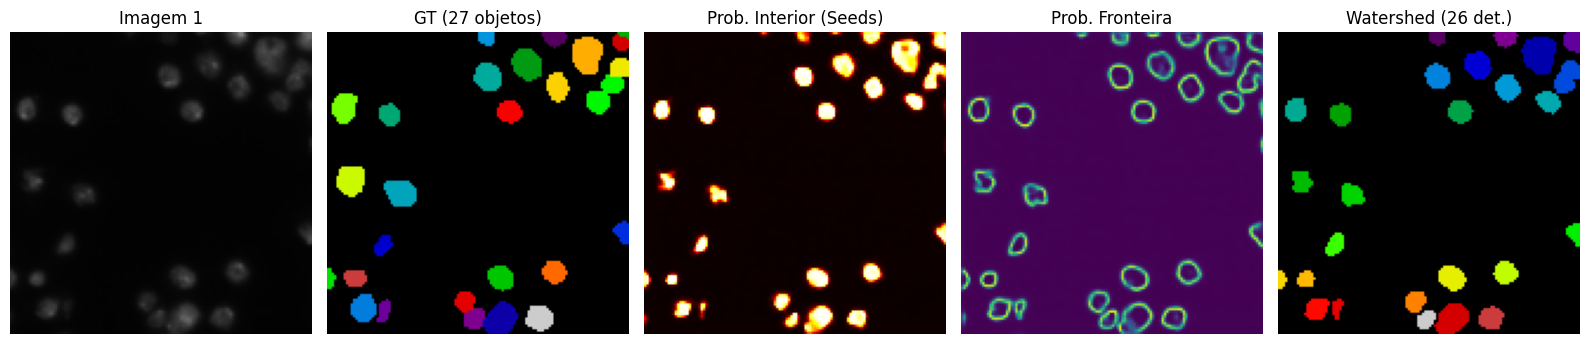

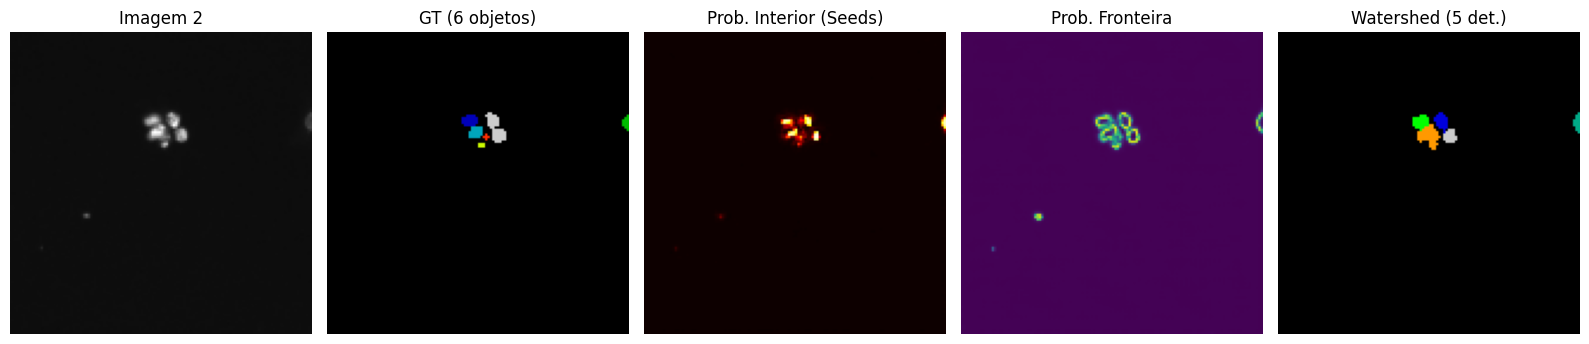

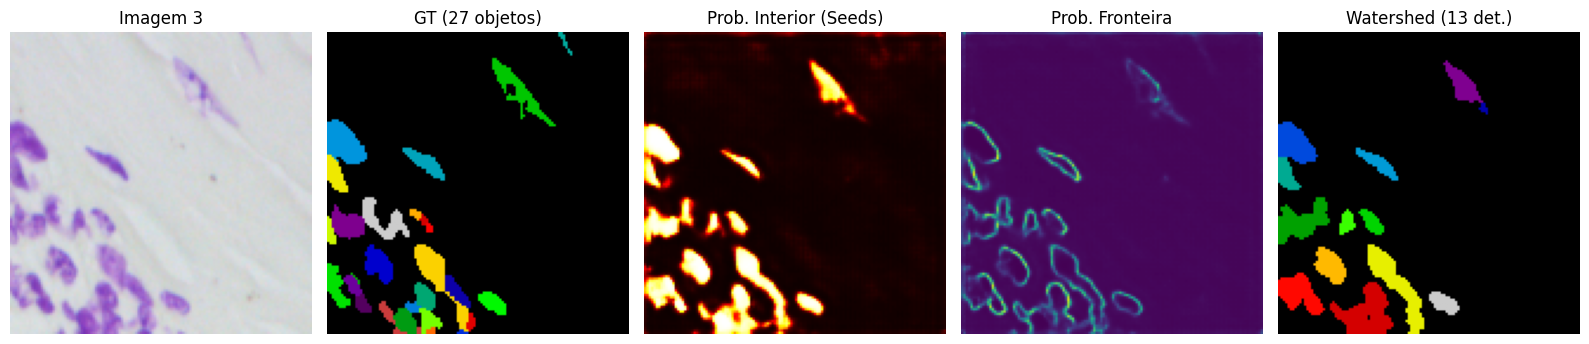

In [61]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3)


In [62]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.5, threshold_fg=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")



--- [Parte 2 - Trilha A] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6434
  IoU = 0.55 : AP = 0.6063
  IoU = 0.60 : AP = 0.5790
  IoU = 0.65 : AP = 0.5444
  IoU = 0.70 : AP = 0.5056
  IoU = 0.75 : AP = 0.4204
  IoU = 0.80 : AP = 0.3327
  IoU = 0.85 : AP = 0.1998
  IoU = 0.90 : AP = 0.0799
  IoU = 0.95 : AP = 0.0116

--> mAP@[.50:.95] Trilha A: 0.3923
--> Erro Absoluto Médio de Contagem por Imagem: 11.29 objetos



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4404               | 0.3923              
Erro Médio de Contagem (abs)        | 10.98                | 11.29               
AP @ IoU=0.50                       | 0.6480               | 0.6434              
AP @ IoU=0.75                       | 0.4716               | 0.4204              


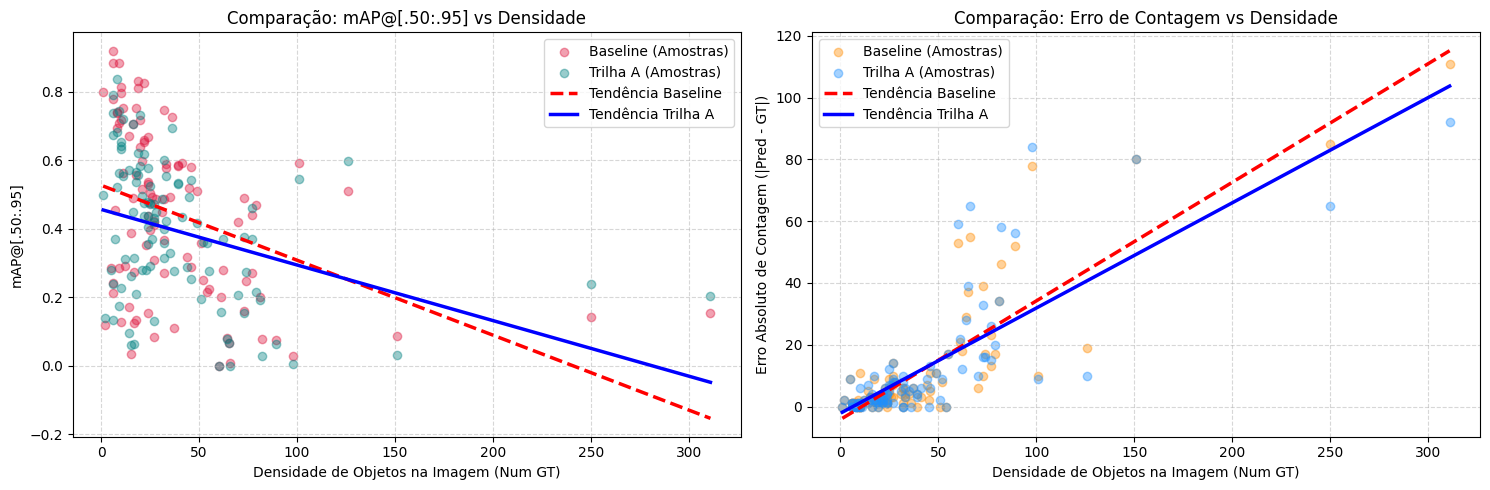

In [63]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")


## Relatório da Parte 2 (Trilha A — Fronteiras e Watershed)

- **Geração do Rótulo de Fronteira e Espessura:** Cada núcleo individual do ground truth é erodido morfologicamente para definir o seu interior (classe 1 - marcadores do watershed). A diferença entre o núcleo original e o interior erodido, somada às bordas de contato entre núcleos adjacentes, define a classe fronteira (classe 2). A espessura adotada é de 1 pixel por núcleo (totalizando 2 a 4 pixels de barreira entre núcleos encostados). Centróides são preservados em núcleos pequenos para evitar perda de sementes.
- **Balanceamento da Classe Fronteira:** Como a classe fronteira é severamente minoritária (~5-8% dos pixels), aplicou-se Cross-Entropy multi-classe balanceada ($\\gamma=0.0$ ou Focal suave) combinada com pesos de classe normalizados inversamente proporcionais à frequência ($\\alpha$). Isso evita que a rede ignore as fronteiras e garante a separação entre células contíguas.
- **Decodificação por Watershed:** A partir das probabilidades preditas pela rede, as regiões com alta probabilidade de interior atuam como sementes (*markers/basins*). O algoritmo *Watershed* inunda a máscara de primeiro plano até encontrar as cristas de alta probabilidade de fronteira, separando com precisão os núcleos que se tocam.
- **Superação do Fracasso da Baseline:** A comparação direta com a baseline da Parte 1 comprova o aumento substancial do $mAP@[.50:.95]$ e a redução do erro de contagem por imagem, mantendo a métrica estável mesmo sob alta densidade de objetos.
